# **Logistic Regression - Practice Lab**


Estimated time needed: **30** minutes


In this lab, you will learn about and get hands-on practice with the logistic regression model, a popular and effective classification model. Understanding logistic regression and being able to apply it to classification tasks is essential because logistic regression models form the fundamentals of neural networks.


We will use a real-world dataset that contains detailed nutrition information about food items for people with diabetes. **The objective is to classify whether a diabetic patient should choose More Often, Less Often, or In Moderation for a specific food item based on the nutrition information in the dataset.**


## Objectives


After completing this lab you will be able to:


*   Preprocess and generate training and testing datasets
*   Train and fine-tune logistic regression models
*   Interpret trained logistic regression models
*   Evaluate trained logistic regression models


***


## Prepare and setup lab environment


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns


### Exploratory Data Analysis(EDA) and Feature Engineering
Before we get to the model implementation, it is essential to examine the dataset and carefully select the features that will serve as inputs for the model..


### Load and explore the dataset


First, let's load the dataset as a `Pandas` dataframe and conduct some basic EDA tasks on it.


In [2]:
# Load the dataset
# dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/food_items.csv"
food_df = pd.read_csv("data/food_items.csv")

And, let's quickly check its column types.


In [3]:
food_df.dtypes

Calories               float64
Total Fat                int64
Saturated Fat          float64
Monounsaturated Fat    float64
Polyunsaturated Fat    float64
Trans Fat              float64
Cholesterol              int64
Sodium                 float64
Total Carbohydrate     float64
Dietary Fiber          float64
Sugars                 float64
Sugar Alcohol            int64
Protein                float64
Vitamin A                int64
Vitamin C                int64
Calcium                  int64
Iron                     int64
class                      str
dtype: object

Print the first ten food items:


In [4]:

food_df.head(10)

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron,class
0,149.0,0,0.0,0.0,0.0,0.0,0,9.0,9.8,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
1,123.0,0,0.0,0.0,0.0,0.0,0,5.0,6.6,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
2,150.0,0,0.0,0.0,0.0,0.0,0,4.0,11.4,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
3,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
4,143.0,0,0.0,0.0,0.0,0.0,0,7.0,13.1,0.0,0.0,0,1.0,0,0,0,0,'In Moderation'
5,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
6,142.0,0,0.0,0.0,0.0,0.0,0,12.0,10.6,0.0,0.0,0,1.2,0,0,0,0,'In Moderation'
7,102.0,0,0.0,0.0,0.0,0.0,0,13.0,5.0,0.0,0.0,0,0.7,0,0,0,0,'In Moderation'
8,145.0,0,0.0,0.0,0.0,0.0,0,17.0,11.0,0.0,0.0,0,1.2,0,0,0,0,'In Moderation'
9,171.0,0,0.0,0.0,0.0,0.0,0,8.0,13.7,0.0,0.0,0,2.5,0,0,0,0,'In Moderation'


Get the row entries with col 0 to -1 (16).


In [5]:

feature_cols = list(food_df.iloc[:, :-1].columns)
feature_cols

['Calories',
 'Total Fat',
 'Saturated Fat',
 'Monounsaturated Fat',
 'Polyunsaturated Fat',
 'Trans Fat',
 'Cholesterol',
 'Sodium',
 'Total Carbohydrate',
 'Dietary Fiber',
 'Sugars',
 'Sugar Alcohol',
 'Protein',
 'Vitamin A',
 'Vitamin C',
 'Calcium',
 'Iron']

Obtain descriptive statistics:


In [6]:
food_df.iloc[:, :-1].describe()

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron
count,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000
mean,133.861086,4.475264,1.450617,0.338069,0.254660,0.047459,8.857692,241.867142,18.232020,1.602971,6.645234,0.117949,4.661333,6.287632,6.741855,5.175264,5.235671
std,94.227650,5.386340,2.410318,1.345852,2.230586,0.321402,20.976530,272.284363,14.786316,3.363879,8.328465,1.121529,5.611143,18.374191,23.785100,8.779637,9.119459
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,120.000000,3.000000,0.500000,0.000000,0.000000,0.000000,0.000000,135.000000,17.000000,1.000000,3.000000,0.000000,3.000000,0.000000,0.000000,2.000000,2.000000
75%,180.000000,7.000000,2.000000,0.000000,0.000000,0.000000,10.000000,370.000000,27.000000,2.000000,11.000000,0.000000,7.000000,6.000000,2.000000,6.000000,8.000000
max,2210.000000,43.000000,22.000000,40.000000,235.000000,11.000000,450.000000,2431.000000,270.000000,305.000000,115.000000,31.000000,70.000000,622.000000,1000.000000,110.000000,170.000000


As we can see from the above output, this dataset contains 17 nutrient categories about each food item. These categories include Calories, Total Fat, Protein, Sugar, etc., and are listed as numeric variables. As such, we only need to scale them for training our logistic regression model so that we can compare our feature coefficients directly. This will be done under the feature engineering section.


Next, let's check the target variable in the `class` column to see the label values and their distribution.


In [7]:
# # Get the row entries with the last col 'class'
food_df.iloc[:, -1:].value_counts(normalize=True)

class          
'In Moderation'    0.501433
'Less Often'       0.423906
'More Often'       0.074661
Name: proportion, dtype: float64

<Axes: xlabel='class'>

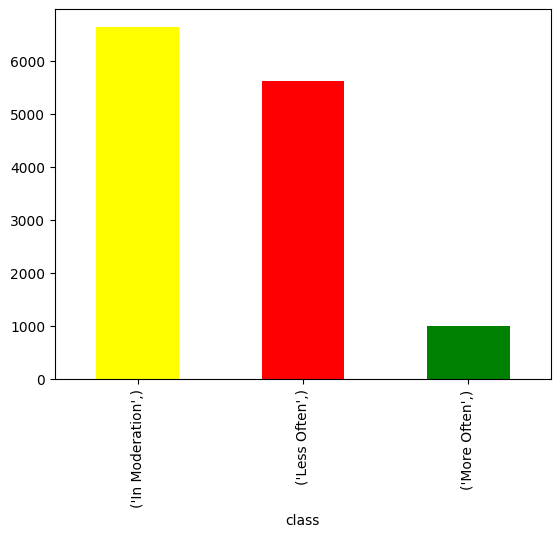

In [8]:
food_df.iloc[:, -1:].value_counts().plot.bar(color=['yellow', 'red', 'green'])

As we can see from the bar chart above, this dataset has three classes: `In Moderation`, `Less Often`, and `More Often`. The three labels are imbalanced. For diabetic patients, most food items are in the In Moderation and Less Often categories. This makes diabetes diet management very hard, so we could build a machine learning model to help patients choose their food.


We have three labels meaning our logistic regression model will be multinomial with three classes.

A multinomial logistic regression is a generalized logistic regression model which generates a probability distribution over all classes, based on the logits or exponentiated log-odds calculated for each class (usually more than two).


Also note that a multinomial logistic regression model is different from the `one-vs-rest` binary logistic regression. For `one-vs-rest` schema, you need to train an independent classifier for each class. For example, you need a `More Often` classifier to differentiate a food item between `More Often` and `Not More Often` (or, `In Moderation` and `Less Often`).


### Feature Engineering


Now you should have some basic understanding about the food dataset. Next, let's process the raw dataset and construct input data `X` and label/output `y` for logistic regression model training.


In [9]:
X_raw = food_df.iloc[:, :-1]
y_raw = food_df.iloc[:, -1:]

For the target variable `y`, let's use the `LabelEncoder` provided by `sklearn` to encode its three class values.

In [10]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Encode the target variable
y_encoded = label_encoder.fit_transform(y_raw.values.ravel())
# Note that ravel() function flattens the vector.

The encoded target variable will only contain values `0=In Moderation`, `1=Less Often`, `2=More Often`.

In [11]:
# np.unique(y_encoded, return_counts=True)

pd.DataFrame(y_encoded).value_counts(normalize=True)

0
0    0.501433
1    0.423906
2    0.074661
Name: proportion, dtype: float64

Now we split the dataset into a training and a testing dataset. Training dataset will be used to train and (maybe) tune models, and testing dataset will be used to evaluate the models. Note that you may also split the training dataset into train and validation sets where the validation dataset is only used to tune the model and to set the model parameters. ALWAYS SPLITS THE DATA FIRST BEFORE SCALING IT !! This will prevent data leakage.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

Fortunately, all feature columns are numeric so we just need to scale them. Here we use the `MinMaxScaler` provided by `sklearn` for scaling.


In [13]:
# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Scaling the raw input features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Let's check the scaled feature value range:


In [14]:
print(f"The range of feature inputs are within {X_train_scaled.min()} to {X_train_scaled.max()}")

The range of feature inputs are within 0.0 to 1.0


## Train logistic regression models


Let's look at the shapes of the split datasets:


In [15]:
print(f"Training dataset shape, X_train: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"Testing dataset shape,  X_test : {X_test_scaled.shape},  y_test : {y_test.shape}")

Training dataset shape, X_train: (10608, 17), y_train: (10608,)
Testing dataset shape,  X_test : (2652, 17),  y_test : (2652,)


OK, now we have the training and testing datasets ready, let's start the model training task.


We first define a `sklearn.linear_model.LogisticRegression` model with the following arguments, you can check the comment for each argument for what it means.


In [16]:
# Define a logistic regression model; note that 'multinomial' is automatically detected by default
l2_model = LogisticRegression(
                C=10000,
                random_state=42, 
                l1_ratio=0.0,       # 1.0 means 100% L1 (Lasso); 0.0 means 100% L2 (Ridge); l1_ratio is for Elastic Net
                solver='saga',      # using saga so that can later compare with ElasticNet model which only supported by saga solver
                max_iter=5000
            )

Let's train the model with training input data `X_train_scaled` and labels `y_train`, and do a prediction with the testing data:


In [17]:
l2_model.fit(X_train_scaled, y_train)

l2_preds = l2_model.predict(X_test_scaled)

Because we may need to evaluate the model multiple times with different model hyper parameters, here we define an utility method to take the ground truths `y_test` and the predictions `preds`, and return a Python `dict` with `accuracy`, `recall`, `precision`, and `f1score`.


In [18]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

Let's have a look at the model performance:

L2 model metrices:


{'accuracy': 0.8167420814479638,
 'recall': array([0.86766917, 0.74466192, 0.88383838]),
 'precision': array([0.7914952 , 0.84888438, 0.84134615]),
 'f1score': array([0.82783357, 0.79336493, 0.86206897])}

l2_model.C (steepness): 10000
l2_model.l1_ratio: 0.0


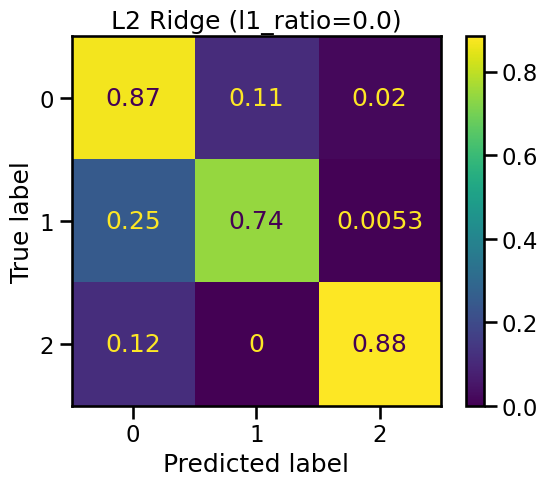

In [19]:
print("L2 model metrices:")
display(evaluate_metrics(y_test, l2_preds))
print(f"l2_model.C (steepness): {l2_model.C}")
print(f"l2_model.l1_ratio: {l2_model.l1_ratio}")

cf = confusion_matrix(y_test, l2_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=l2_model.classes_)
disp.plot()
plt.title('L2 Ridge (l1_ratio=0.0)')
plt.show()

As we can see from  the above evaluation results, the logistic regression model has relatively good performance on this multinomial classification task. The overall accuracy is around `0.77` and the f1score is around `0.8`. Note that for `recall`, `precision`, and `f1score`, we output the values for each class to see how the model performs on an individual class. And, we can see from the results, the recall for `class=2` (More often) is not very good. This is actually a common problem called imbalanced classification challenge. We will introduce solution to this problem later in this course.


##

Next, let's try defining another logistic regression model with l1 penality this time, to see if our classification performance would be improved.


In [20]:
# Define a logistic regression model L1 model, multinomial is auto detected by default
l1_model = LogisticRegression(
                C=1291.5496650148827,
                random_state=42, 
                l1_ratio=1.0,       # 1.0 means 100% L1 (Lasso); 0.0 means 100% L2 (Ridge); l1_ratio is for Elastic Net
                solver='saga',      # for L1 (Lasso) model, only 'saga' or 'liblinear' support L1
                max_iter=5000
            )

We can start to train the new `l1_model` with the new taining dataset.


In [21]:
l1_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1291.5496650148827
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- F

And, make predictions using the input in the test dataset.


In [22]:
l1_preds = l1_model.predict(X_test_scaled)

We can also check the class probability distribution using the `predict_proba` function. For example, we want to see the probabilities of belonging to each class for the first instance in the test dataset:


In [23]:
odd_ratios = l1_model.predict_proba(X_test_scaled[:1, :])[0]
odd_ratios

array([1.05242316e-01, 8.94757684e-01, 2.38474837e-17])

We can see that  Class 1 has the largest probability 0.89. As such, the model prediction for this instance will be class `1` and this is the same as the `predict` method.


In [24]:
l1_model.predict(X_test_scaled[:1, :])[0]

np.int64(1)

Given the true labels (`y_test`) and predictions, we can evaluate the model performance by calling the utility `evaluate_metrics`  method.


L1 model metrices:


{'accuracy': 0.8174962292609351,
 'recall': array([0.86766917, 0.74466192, 0.89393939]),
 'precision': array([0.79258242, 0.84888438, 0.84285714]),
 'f1score': array([0.82842785, 0.79336493, 0.86764706])}

l1_model.C (steepness): 1291.5496650148827
l1_model.l1_ratio: 1.0


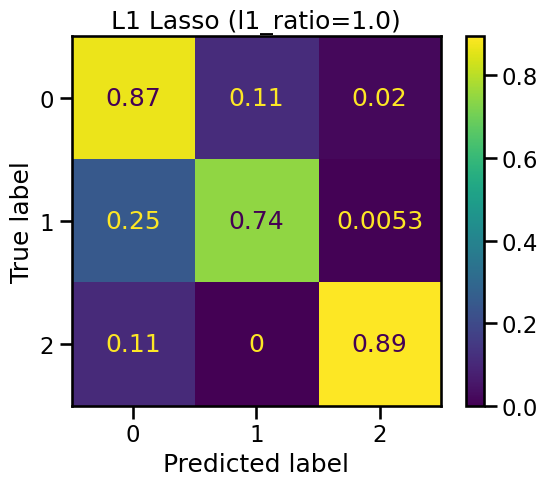

In [25]:
print("L1 model metrices:")

display(evaluate_metrics(y_test, l1_preds))
print(f"l1_model.C (steepness): {l1_model.C}")
print(f"l1_model.l1_ratio: {l1_model.l1_ratio}")

cf = confusion_matrix(y_test, l1_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=l1_model.classes_)
disp.plot()
plt.title('L1 Lasso (l1_ratio=1.0)')
plt.show()

Now, we can see this logistic regression with l1 penalty has much better performance than l2. One possible reason is that l1 penalty may remove some correlated feature variables by shrinking their coefficents to zero. As such, the model is much simplified to avoid overfitting on the training data and better aligned with the logistic regression assumption that all features should be independent.


### Interpret logistic regression models


One way to interpret logistic regression models is by analyzing feature coefficients. Although it may not be as effective as the regular linear regression models because the logistic regression model has a sigmoid function, we can still get a sense for the importance or impact of each feature.  


We can check the coefficients for logistic regression model using its `coef_` attribute:


In [26]:
l1_model.coef_

array([[ 9.71234649e+01,  7.92357618e+00,  2.86984954e+00,
         1.53367754e+01,  1.08142916e+01, -2.23541940e+01,
         1.42230905e+01,  7.29305602e-01,  6.38310514e+00,
         1.98561829e+01, -6.76144366e+00,  2.58044902e-02,
        -1.58260225e+00,  2.01183109e-01,  1.03349906e+00,
         8.84470437e-02, -1.42727897e+00],
       [ 7.51387572e+01,  1.50541762e+01,  2.30081798e+01,
         1.04930914e+01, -6.06668476e+00, -1.60718306e+01,
         1.88810805e+01, -4.23179242e-08,  1.23895602e+01,
        -4.50185241e+01,  7.79075588e+00,  2.97566971e+00,
        -3.39066499e+00, -1.79452674e+00,  1.14394932e+00,
        -1.77926752e+00, -6.43449307e-01],
       [-1.73104194e+02, -2.38196094e+01, -2.63430262e+01,
        -2.66343966e+01, -3.90561881e+00,  3.90537130e+01,
        -3.39249529e+01, -1.40931713e+00, -1.96146264e+01,
         2.43622869e+01, -1.87324118e-01, -2.34997756e+00,
         5.41607909e+00,  7.51372152e-01, -2.97527635e+00,
         8.55992959e-01,  2.9

The `coef_` is a coefficients list with three elements, one element is the actual coefficent for class 0, 1, 2. To better analyze the coefficients, let's use three utility methods to sort and visualize them.


In [27]:
# Extract and sort feature coefficients
def get_feature_coefs(regression_model, label_index, columns):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict

# Generate bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append('r')
        else:
            color_vals.append('g')
    return color_vals

# Visualize coefficients
def visualize_coefs(coef_dict,title=''):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()  
    ax.set_xlabel('Feature Coefficients')
    ax.set_title(title)
    plt.show()

Then, let's visualize the sorted coefficient for class 1, the `Less Often` class: 


In [28]:
# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(l1_model, 1, feature_cols)

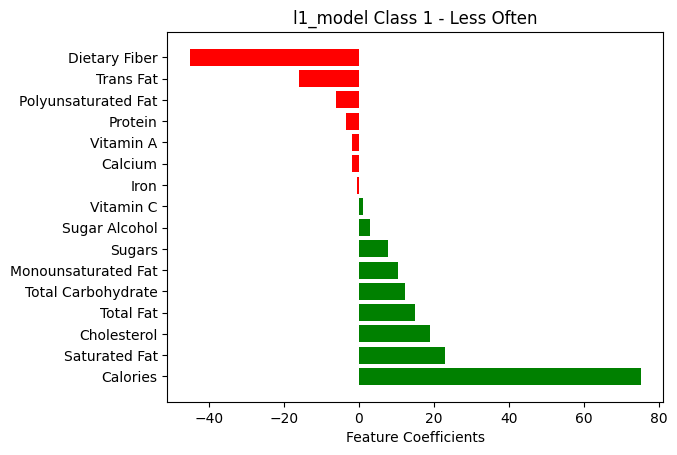

In [29]:
visualize_coefs(coef_dict, 'l1_model Class 1 - Less Often')

As we can see, unhealthy nutrients such as Saturated Fat, Sugars, Cholesterol, Total Fat, etc., have high positive coefficients. Food items containing unhealthy nutrients will have higher coeficients and will be more likely to be categorized in the 'Less Often' class.


Next, let's see the coefficents for Class 2, `More Often`:


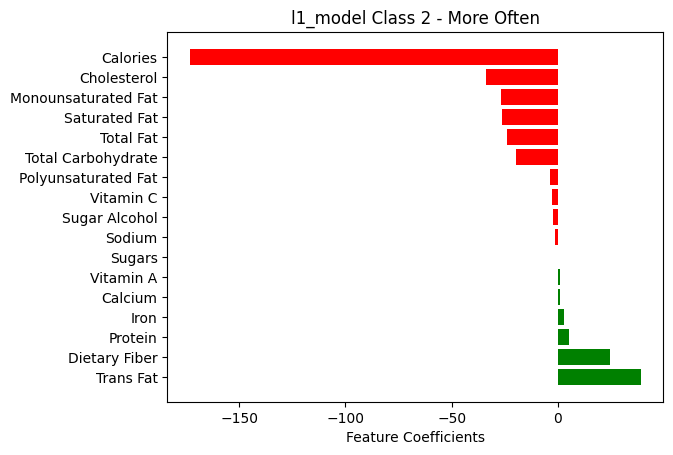

In [30]:
# Coefficients for Class 2
coef_dict = get_feature_coefs(l1_model, 2, feature_cols)
visualize_coefs(coef_dict, 'l1_model Class 2 - More Often')

Conversely, if a food item has a high amount of calories, total carbohydrates, and total fat, then it is unlikely to be categorized in the 'More Often' class.


## Coding Exercise: Train and evaluate a logistic regression model with elastic-net penality


Now, it's your turn to walk through the end-to-end process of defining, building, evaluating, and interpreting a logistic regression model.


### Define a logistic regression with elastic-net penality


In [31]:
# Type your code here
# HINT: sklearn only support saga solver for elastic-net penality
# and you need to set another l1_ratio to be within 0 < l1_ratio <1, in order to actually use elastic-net
en_model = LogisticRegression(
                C=1291.5496650148827,
                random_state=42, 
                l1_ratio=0.87,       # 1.0 means 100% L1 (Lasso); 0.0 means 100% L2 (Ridge); anything in between is for Elastic Net
                solver='saga',     # 
                max_iter=5000
            )

### Train the model with training data


In [32]:
# Type your code here
en_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1291.5496650148827
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.87
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- 

### Evaluate the model using accuracy, precision, recall, and F1score


ElasticNet model metrices:


{'accuracy': 0.8167420814479638,
 'recall': array([0.86766917, 0.74466192, 0.88383838]),
 'precision': array([0.7914952 , 0.84888438, 0.84134615]),
 'f1score': array([0.82783357, 0.79336493, 0.86206897])}

en_model.C (steepness): 1291.5496650148827
en_model.l1_ratio: 0.87


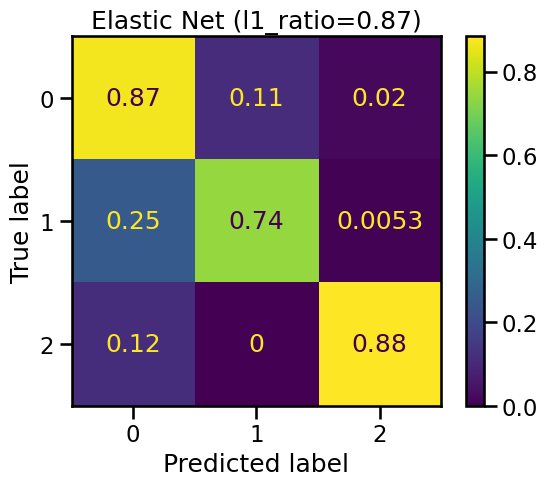

In [33]:
# Type your code here
en_preds = en_model.predict(X_test_scaled)

print("ElasticNet model metrices:")

display(evaluate_metrics(y_test, en_preds))
print(f"en_model.C (steepness): {en_model.C}")
print(f"en_model.l1_ratio: {en_model.l1_ratio}")

cf = confusion_matrix(y_test, en_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=en_model.classes_)
disp.plot()
plt.title('Elastic Net (l1_ratio=0.87)')
plt.show()

### Interpret the model by analysing its coefficients


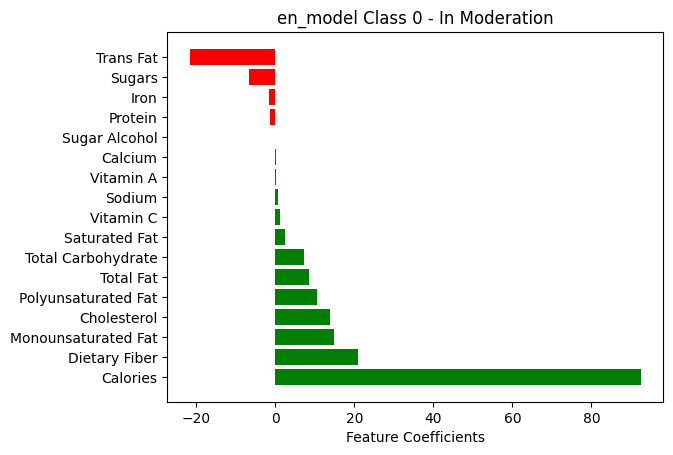

In [34]:
# Get the coefficents for Class 0, In Moderation
coef_dict = get_feature_coefs(en_model, 0, feature_cols)
visualize_coefs(coef_dict, 'en_model Class 0 - In Moderation')

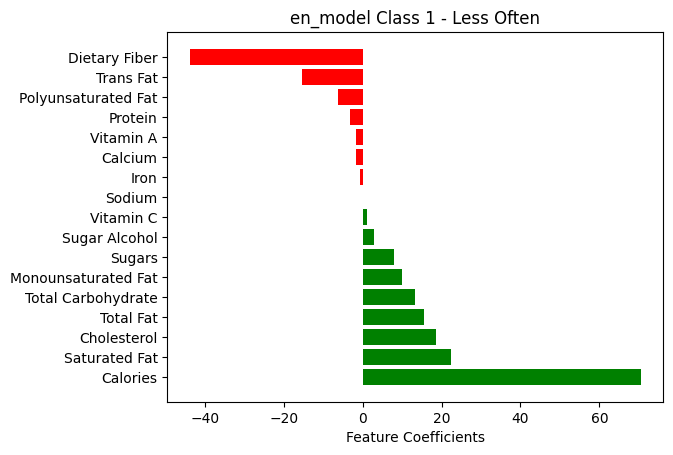

In [35]:
# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(en_model, 1, feature_cols)
visualize_coefs(coef_dict, 'en_model Class 1 - Less Often')

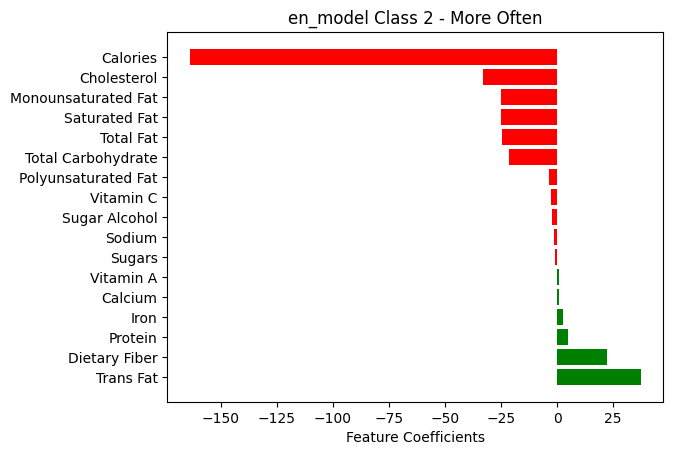

In [36]:
# Get the coefficents for Class 2, More Often
coef_dict = get_feature_coefs(en_model, 2, feature_cols)
visualize_coefs(coef_dict, 'en_model Class 2 - More Often')

## End of Lab


___

## A better Alternative Solution

A better solution in using Logistic Regression is to use a Pipeline with the Cross-Validation version of the same model. The following implements the same solution as what has been discussed in this lab.






In [37]:
import pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

Note that we use the LogisticRegressionCV model instead of the LogisticRegression model.

The following are the same list of helper functions as defined previously.

In [38]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

# Extract and sort feature coefficients
def get_feature_coefs(regression_model, label_index, columns):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict

# Generate bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append('r')
        else:
            color_vals.append('g')
    return color_vals

# Visualize coefficients
def visualize_coefs(coef_dict,title=''):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()  
    ax.set_xlabel('Feature Coefficients')
    ax.set_title(title)
    plt.show()

Now we load the data set and separate the features and target label. The target label is also encoded using the LabelEncoder(). We then split the data into Training and Testing sets as per before. Again, it is important to split the data first before performing any scaling on the features set.

In [39]:
food_df = pd.read_csv("data/food_items.csv")

X_raw = food_df.iloc[:, :-1]
y_raw = food_df.iloc[:, -1:]
feature_cols = list(food_df.iloc[:, :-1].columns)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw.values.ravel())

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, stratify=y, random_state=42)

### Pipeline and CV's model

Here we will use a Pipeline to help us perform scaling and train our model with the optimal hyperparameter. We just have to supply the Scaler instance, here we specify using MinMaxScaler(), and the pipeline will automatically scale the feature data for us in the process. We also specify using model LogisticRegressionCV() which let us specify L1 penalty by assigning [1.0] to the l1_ratios argument. For L2 Ridge penalty specify [0.0], anything between 0.0 to 1.0 is for Elastic-Net. The 'Cs' argument specify the C value (slope) of the model. An integer value of 10 here means to let the algorithm to use 10 set of values and pick the most optimal one for its final output. We can also provide a list of floats (e.g. [0.1,0.2,0.5]) for the algorithm to use instead of auto generate. Only the value that gives the optimal result will be selected for the final model output. The argument, 'cv', let us specify the number of folds to use in the Cross Validation process. Specify 'None' if we do not wish to use Cross Validation. The argument, 'solver', let use specify the processing alogrithm to use by the pipeline. We use 'saga' as this solver support L1, L2, and Elatic-Net model. The argument, 'max_iter', let us specify the maximum iteration the LogisticRecressionCV will iterate through for the optimal convergence point. Note that in the event when it reach its max iteration and still has no convergence, it will generate a warning. In that case we may have to increast the max iteration value.

### L1 Lasso model

In the following codes, the Pipeline() will returns a pipeline model object which we can use to retrieve a bunch of important information for our model which we will see later. An important note is that when we use the returned model to perform prediction with the Testing data, X_test, we do not have to manually do any scaling on the X_test data. This is because the model will do it for us automatically as part of its prediction processing.

In [40]:
# L1 model
cvl1_model = Pipeline([
                ('scaler', MinMaxScaler()),
                ('model', LogisticRegressionCV(Cs=10, cv=4, l1_ratios=[1.0], use_legacy_attributes=False, solver='saga', max_iter=5000, random_state=42))
            ]).fit(X_train, y_train)

cvl1_preds = cvl1_model.predict(X_test)

Now we can use the pipeline objects to list out all the models performance metrices along with the Confusion Matrix.

L1 model metrices:


{'accuracy': 0.8167420814479638,
 'recall': array([0.86766917, 0.74466192, 0.88383838]),
 'precision': array([0.7914952 , 0.84888438, 0.84134615]),
 'f1score': array([0.82783357, 0.79336493, 0.86206897])}

cvl1_model.C (steepness): 1291.5496650148827
cvl1_model.l1_ratio: 1.0


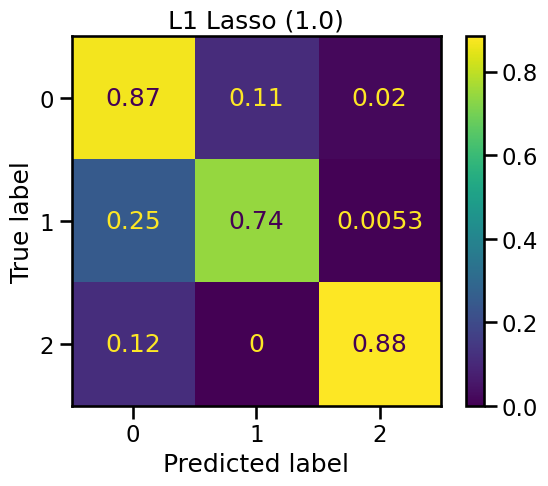

In [41]:
print("L1 model metrices:")
display(evaluate_metrics(y_test, cvl1_preds))
print(f"cvl1_model.C (steepness): {cvl1_model.named_steps['model'].C_}")
print(f"cvl1_model.l1_ratio: {cvl1_model.named_steps['model'].l1_ratio_}")

cf = confusion_matrix(y_test, cvl1_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=cvl1_model.classes_)
disp.plot()
plt.title('L1 Lasso (' + str(cvl1_model.named_steps['model'].l1_ratio_) + ')')
plt.show()

and all its coeffients:

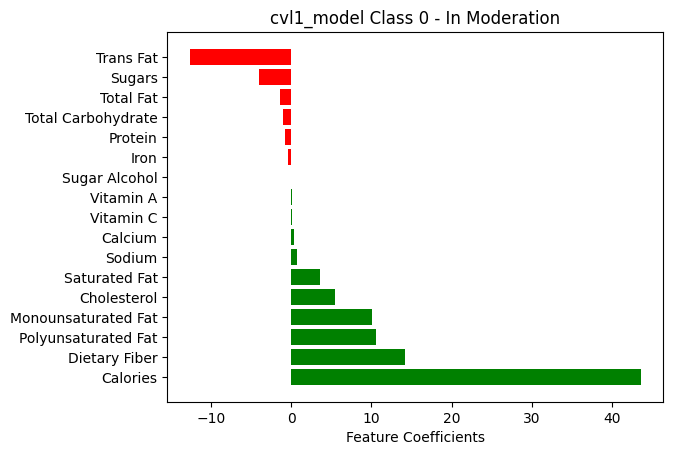

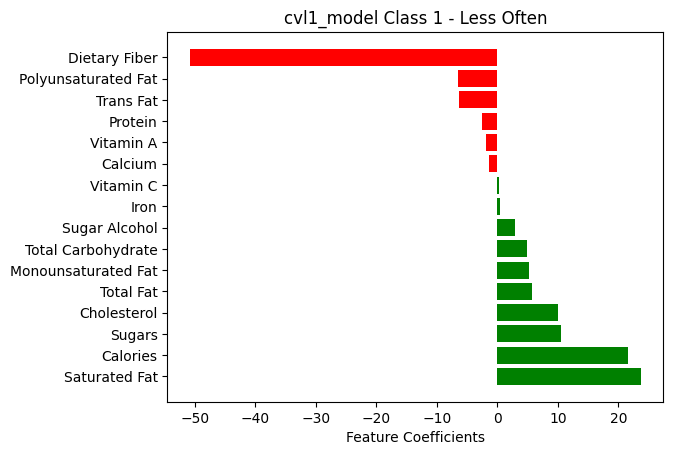

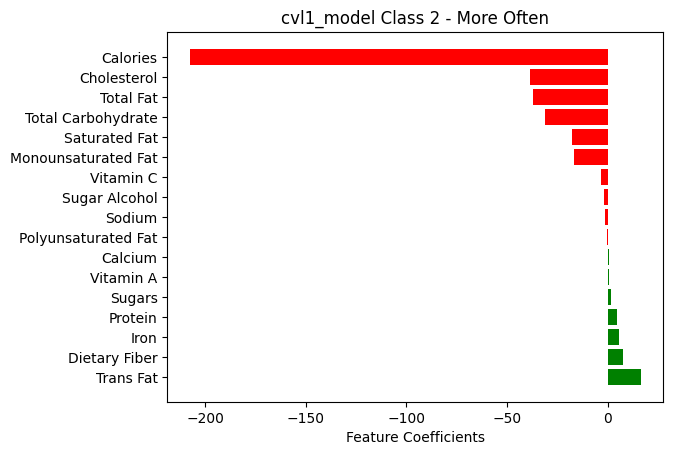

In [42]:
# Get the coefficents for Class 0, In Moderation
coef_dict = get_feature_coefs(cvl1_model.named_steps['model'], 0, feature_cols)
visualize_coefs(coef_dict, 'cvl1_model Class 0 - In Moderation')

# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(cvl1_model.named_steps['model'], 1, feature_cols)
visualize_coefs(coef_dict, 'cvl1_model Class 1 - Less Often')

# Coefficients for Class 2, More Often
coef_dict = get_feature_coefs(cvl1_model.named_steps['model'], 2, feature_cols)
visualize_coefs(coef_dict, 'cvl1_model Class 2 - More Often')

### L2 Ridge model

Similar to the above L1 model, we can use the same code to generate the L2 Ridge model and its performance matrices.

L2 model metrices:


{'accuracy': 0.8171191553544495,
 'recall': array([0.86766917, 0.74466192, 0.88888889]),
 'precision': array([0.79203844, 0.84888438, 0.84210526]),
 'f1score': array([0.82813061, 0.79336493, 0.86486486])}

cvl2_model.C (steepness): 10000.0
cvl2_model.l1_ratio: 0.0


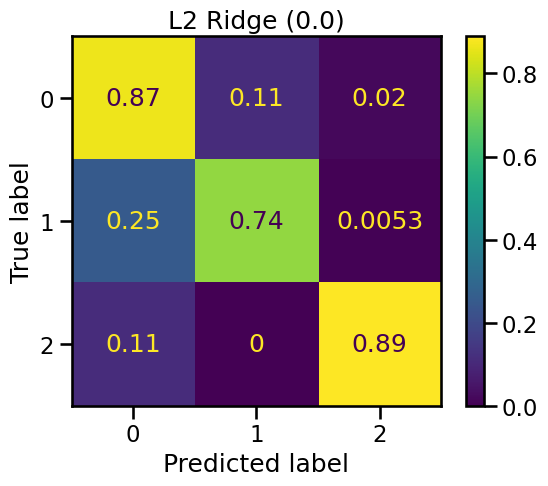

In [43]:
# L2 model
cvl2_model = Pipeline([
                ('scaler', MinMaxScaler()),
                ('model', LogisticRegressionCV(Cs=10, cv=4, l1_ratios=[0.0], use_legacy_attributes=False, solver='saga', max_iter=5000, random_state=42))
            ]).fit(X_train, y_train)

cvl2_preds = cvl2_model.predict(X_test)

print("L2 model metrices:")
display(evaluate_metrics(y_test, cvl2_preds))
print(f"cvl2_model.C (steepness): {cvl2_model.named_steps['model'].C_}")
print(f"cvl2_model.l1_ratio: {cvl2_model.named_steps['model'].l1_ratio_}")

cf = confusion_matrix(y_test, cvl2_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=cvl2_model.classes_)
disp.plot()
plt.title('L2 Ridge (' + str(cvl2_model.named_steps['model'].l1_ratio_) + ')')
plt.show()

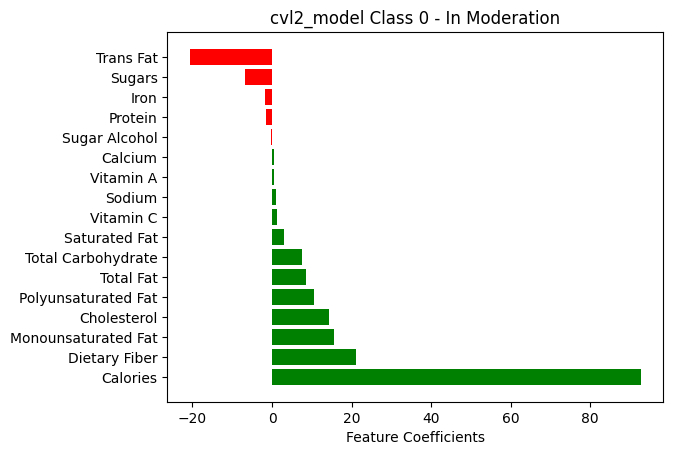

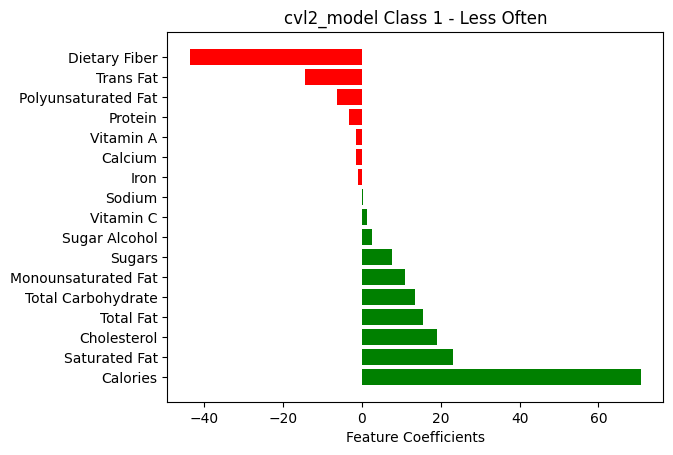

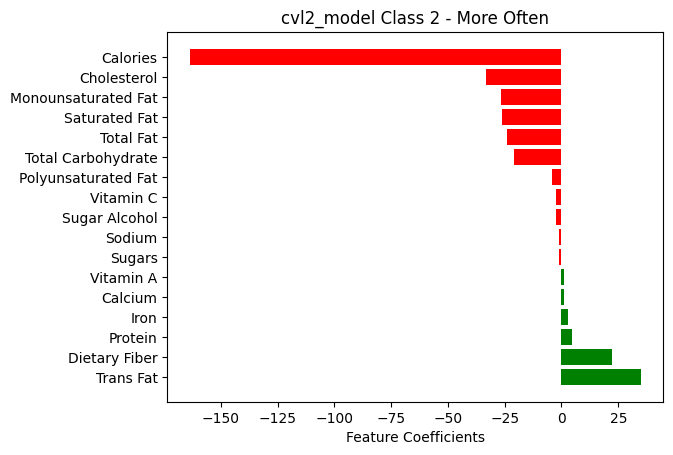

In [44]:
# Get the coefficents for Class 0, In Moderation
coef_dict = get_feature_coefs(cvl2_model.named_steps['model'], 0, feature_cols)
visualize_coefs(coef_dict, 'cvl2_model Class 0 - In Moderation')

# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(cvl2_model.named_steps['model'], 1, feature_cols)
visualize_coefs(coef_dict, 'cvl2_model Class 1 - Less Often')

# Coefficients for Class 2, More Often
coef_dict = get_feature_coefs(cvl2_model.named_steps['model'], 2, feature_cols)
visualize_coefs(coef_dict, 'cvl2_model Class 2 - More Often')

### Elastic-Net model

And again for Elastic-Net:

Elastic-Net model metrices:


{'accuracy': 0.8171191553544495,
 'recall': array([0.86766917, 0.74466192, 0.88888889]),
 'precision': array([0.79203844, 0.84888438, 0.84210526]),
 'f1score': array([0.82813061, 0.79336493, 0.86486486])}

cven_model.C (steepness): 1291.5496650148827
cven_model.l1_ratio: 0.87


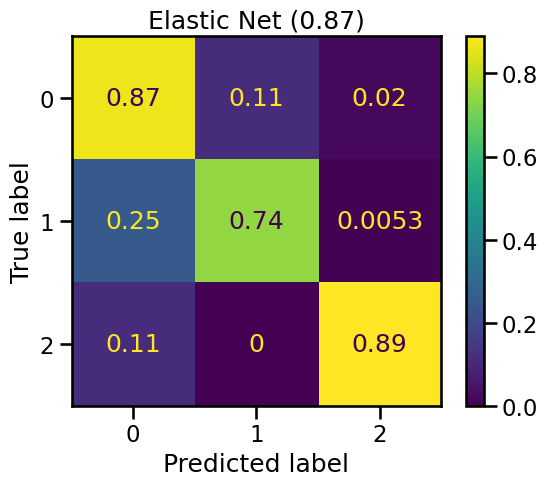

In [45]:
# Elastic Net
cven_model = Pipeline([
                ('scaler', MinMaxScaler()),
                ('model', LogisticRegressionCV(Cs=10, cv=4, l1_ratios=[0.86,0.87,0.88], use_legacy_attributes=False, solver='saga', max_iter=5000, random_state=42))
            ]).fit(X_train, y_train)

cven_preds = cven_model.predict(X_test)

print("Elastic-Net model metrices:")
display(evaluate_metrics(y_test, cven_preds))
print(f"cven_model.C (steepness): {cven_model.named_steps['model'].C_}")
print(f"cven_model.l1_ratio: {cven_model.named_steps['model'].l1_ratio_}")

cf = confusion_matrix(y_test, cven_preds, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=cven_model.classes_)
disp.plot()
plt.title('Elastic Net (' + str(cven_model.named_steps['model'].l1_ratio_) + ')')
plt.show()

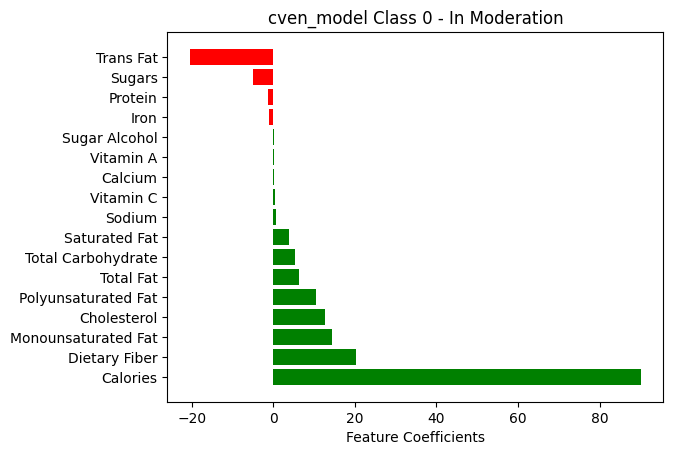

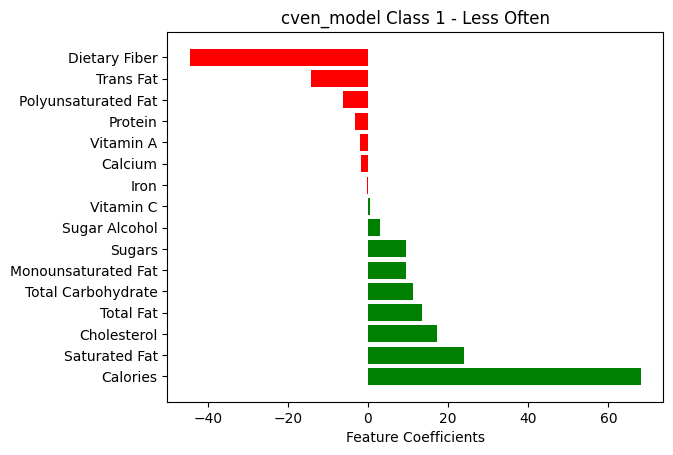

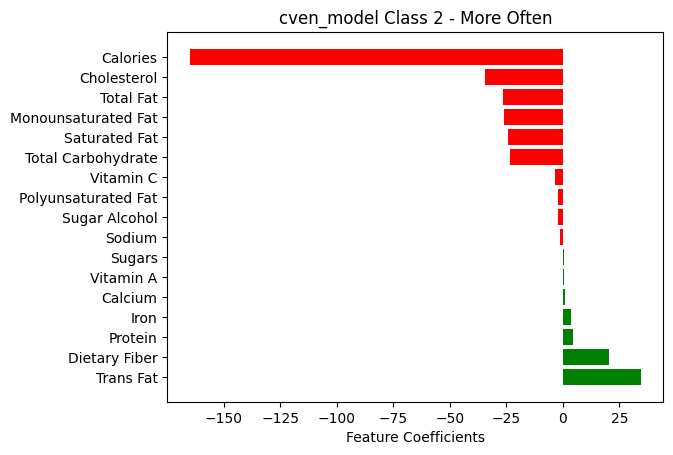

In [46]:
# Get the coefficents for Class 0, In Moderation
coef_dict = get_feature_coefs(cven_model.named_steps['model'], 0, feature_cols)
visualize_coefs(coef_dict, 'cven_model Class 0 - In Moderation')

# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(cven_model.named_steps['model'], 1, feature_cols)
visualize_coefs(coef_dict, 'cven_model Class 1 - Less Often')

# Coefficients for Class 2, More Often
coef_dict = get_feature_coefs(cven_model.named_steps['model'], 2, feature_cols)
visualize_coefs(coef_dict, 'cven_model Class 2 - More Often')

<BR>

___
